In [21]:
from data_gen import *
from circuit_construction import *
from params_construction import *
from representatives import *
from pack_unpack_params import *
from cost_functions import *
from predict import *
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity
from scipy.optimize import minimize

In [11]:
def make_train_set(problem, N):
    
    train = data_generator(problem, N)
    x_train = []
    y_train = []

    for i in range(len(train)):
        x_train.append(train[i][0])
        y_train.append(train[i][1])

    return x_train, y_train

x_train, y_train = make_train_set('circle', 200)

In [12]:
def make_text_set(problem, N):
    
    text = data_generator(problem, N)
    x_text = []
    y_text = []
    
    for i in range(len(text)):
        x_text.append(text[i][0])
        y_text.append(text[i][1])
    
    return x_text, y_text

x_text, y_text = make_text_set('circle', 1000)

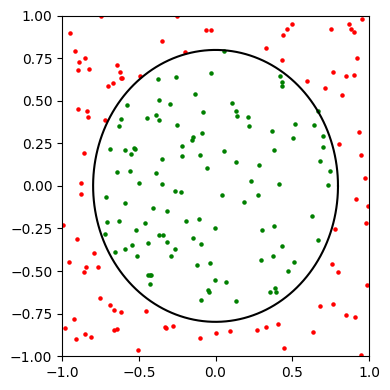

In [13]:
fig, ax = plt.subplots(1,1, figsize =(4,4))
theta_circle = np.linspace(0, 2*np.pi, 500)
r = np.sqrt(2/np.pi)
ax.plot(r*np.cos(theta_circle), r*np.sin(theta_circle), 'k-', label = 'True circle')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
colors = ['r', 'g']
for i in range(len(x_train)):
    c = colors[y_train[i]]
    ax.scatter(x_train[i][0], x_train[i][1], c= c, s=5)
plt.tight_layout()
plt.show()

In [ ]:
theta, w, alpha = params_construction(2, 2, 2)
print(theta,'\n', w,'\n',  alpha)

qc = []
for x in x_train:
    qc.append(circuit(2,2,theta, w, x))


qc[0].draw()

[[[4.14363655 4.96618331 3.78116771]
  [5.41669827 4.44631217 5.59908296]]

 [[2.38285883 2.80599478 0.89213097]
  [3.06086145 4.48392771 3.11732556]]] 
 [[[0.10204127 0.49738996 0.5548873 ]
  [0.2285297  0.11313901 0.2101206 ]]

 [[0.19546218 0.12398894 0.91429893]
  [0.03142495 0.40549486 0.8949078 ]]] 
 [[0.83495302 0.94781219]
 [0.15287689 0.78884832]]


┌────────────┐┌────────────┐┌────────────┐┌────────────┐┌────────────┐»
q_0: ─┤ Rz(3.7812) ├┤ Ry(4.0965) ├┤ Rz(4.8576) ├┤ Rz(5.5991) ├┤ Ry(5.3111) ├»
     ┌┴────────────┤├────────────┤├────────────┤├────────────┤├────────────┤»
q_1: ┤ Rz(0.89213) ├┤ Ry(2.2926) ├┤ Rz(2.7789) ├┤ Rz(3.1173) ├┤ Ry(3.0463) ├»
     └─────────────┘└────────────┘└────────────┘└────────────┘└────────────┘»
«     ┌────────────┐
«q_0: ┤ Rz(4.4216) ├
«     ├────────────┤
«q_1: ┤ Rz(4.3954) ├
«     └────────────┘

In [ ]:
n_qubits = 2
n_layers = 2
n_classes = 2

reprs = representatives(n_classes,1)
params= pack_params(theta, w, alpha) 

iteration = [0]

def callback(params):

    iteration[0] += 1
    cost = weighted_cost_function(params, n_qubits, n_layers, n_classes, x_train, y_train, reprs)

    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun=weighted_cost_function,
    x0=params,
    args=(n_qubits,n_layers, n_classes, x_train, y_train, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 50,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)

theta_opt, w_opt, alpha_opt = unpack_params(result.x, n_qubits, n_layers, n_classes)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")
            

Iteration 1, cost: 60.611911
Iteration 2, cost: 54.178379
Iteration 3, cost: 51.080938
Iteration 4, cost: 49.313851
Iteration 5, cost: 45.161280
Iteration 6, cost: 38.960418
Iteration 7, cost: 34.501493
Iteration 8, cost: 31.747003
Iteration 9, cost: 30.791320
Iteration 10, cost: 30.621664
Iteration 11, cost: 30.601244
Iteration 12, cost: 30.486416
Iteration 13, cost: 30.413546
Iteration 14, cost: 30.334608
Iteration 15, cost: 30.292623
Iteration 16, cost: 30.134863
Iteration 17, cost: 30.000622
Iteration 18, cost: 29.744443
Iteration 19, cost: 29.248528
Iteration 20, cost: 28.597440
Iteration 21, cost: 28.001747
Iteration 22, cost: 26.691830
Iteration 23, cost: 25.037578
Iteration 24, cost: 23.152994
Iteration 25, cost: 21.924192
Iteration 26, cost: 19.086654
Iteration 27, cost: 16.930832
Iteration 28, cost: 15.917923
Iteration 29, cost: 14.896376
Iteration 30, cost: 14.179681
Iteration 31, cost: 13.919169
Iteration 32, cost: 13.729516
Iteration 33, cost: 13.690007
Iteration 34, cost:

In [15]:
print(theta_opt, w_opt, alpha_opt)

[[[1.48565807 2.64327694 3.5222533 ]
  [2.23197914 5.33351729 2.5287894 ]]

 [[1.55644274 5.22376394 2.16184526]
  [4.72260099 5.52267553 4.19925351]]] [[[-0.3442467  -0.00291049  0.10029539]
  [ 0.71117624  0.37503651  0.75481068]]

 [[ 1.47638214 -1.64505947  0.22654712]
  [-0.12320191  0.37382107  0.259019  ]]] [[-1.13355109  2.6190113 ]
 [-1.7617918   2.5652039 ]]


In [ ]:
preds = predict(x_text, n_qubits, n_layers, n_classes, 
                theta_opt, w_opt, alpha_opt, reprs)
accuracy = np.mean(preds == y_text)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9610


10 iteration circa 3 min

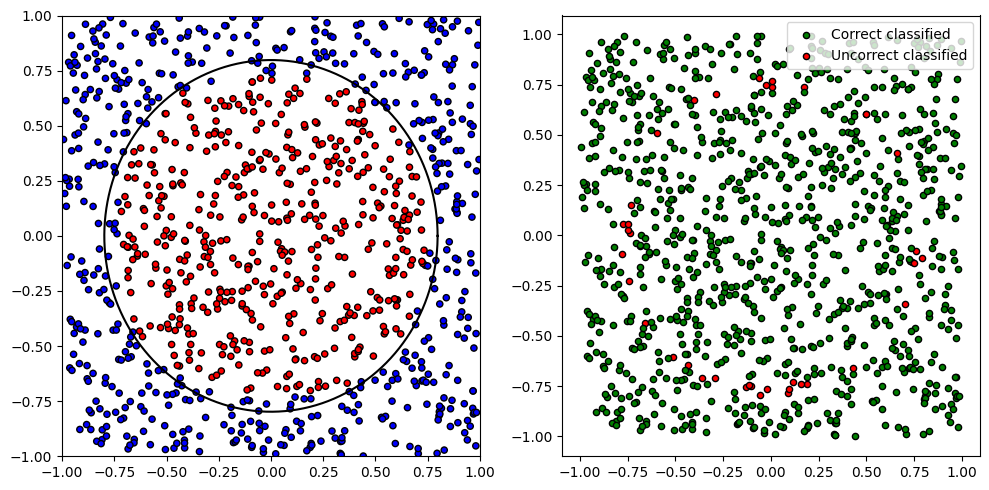

In [ ]:
fig, ax = plt.subplots(1,2, figsize =(10,5 ))
theta_circle = np.linspace(0, 2*np.pi, 500)
r = np.sqrt(2/np.pi)
ax[0].plot(r*np.cos(theta_circle), r*np.sin(theta_circle),'k-', label = 'True circle')
ax[0].set_xlim(-1,1)
ax[0].set_ylim(-1,1)

ax[0].scatter(x_text[:, 0], x_text[:, 1], c= preds, cmap='bwr', edgecolors='k',s=20)

labels = []
for i in range(len(x_text)):
    if preds[i] == y_text[i]:
        label = 'Correct classified' if 'Correct classified' not in labels else None
        ax[1].scatter(x_text[i, 0], x_text[i, 1], c= 'g', edgecolors='k',s=20, label= label)
        labels.append(label)
    else:
        label = 'Uncorrect classified' if 'Uncorrect classified' not in labels else None
        ax[1].scatter(x_text[i, 0], x_text[i, 1], c= 'r', edgecolors='k',s=20, label= label)
        labels.append(label)
        
ax[1].legend()
plt.tight_layout()
plt.show()